# Find atom position in HRTEM image using Blob detection and image segmentation

In [1]:
"""
Load file
"""

import easygui
import cv2
import tifffile

# path =  easygui.fileopenbox("Select the IFFT stack") # This easygui package works for windows, but not for mac
## for mac, option+right click the file, copy as pathname and paste 
path = input("Input pathname for IFFT movie: ").strip("'")
img = tifffile.imread(path)

# pathr =  easygui.fileopenbox("Select the image tiff stack")
pathr = input("Input pathname for TEM movie: ").strip("'")

Rimg = tifffile.imread(pathr)

Input pathname for IFFT movie:  '/Volumes/Samsung T7/UNet data/IFFT Movie.tif'
Input pathname for TEM movie:  '/Volumes/Samsung T7/UNet data/HRTEM Movie.tif'


In [3]:
# Change width of Jupyter Notebook
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

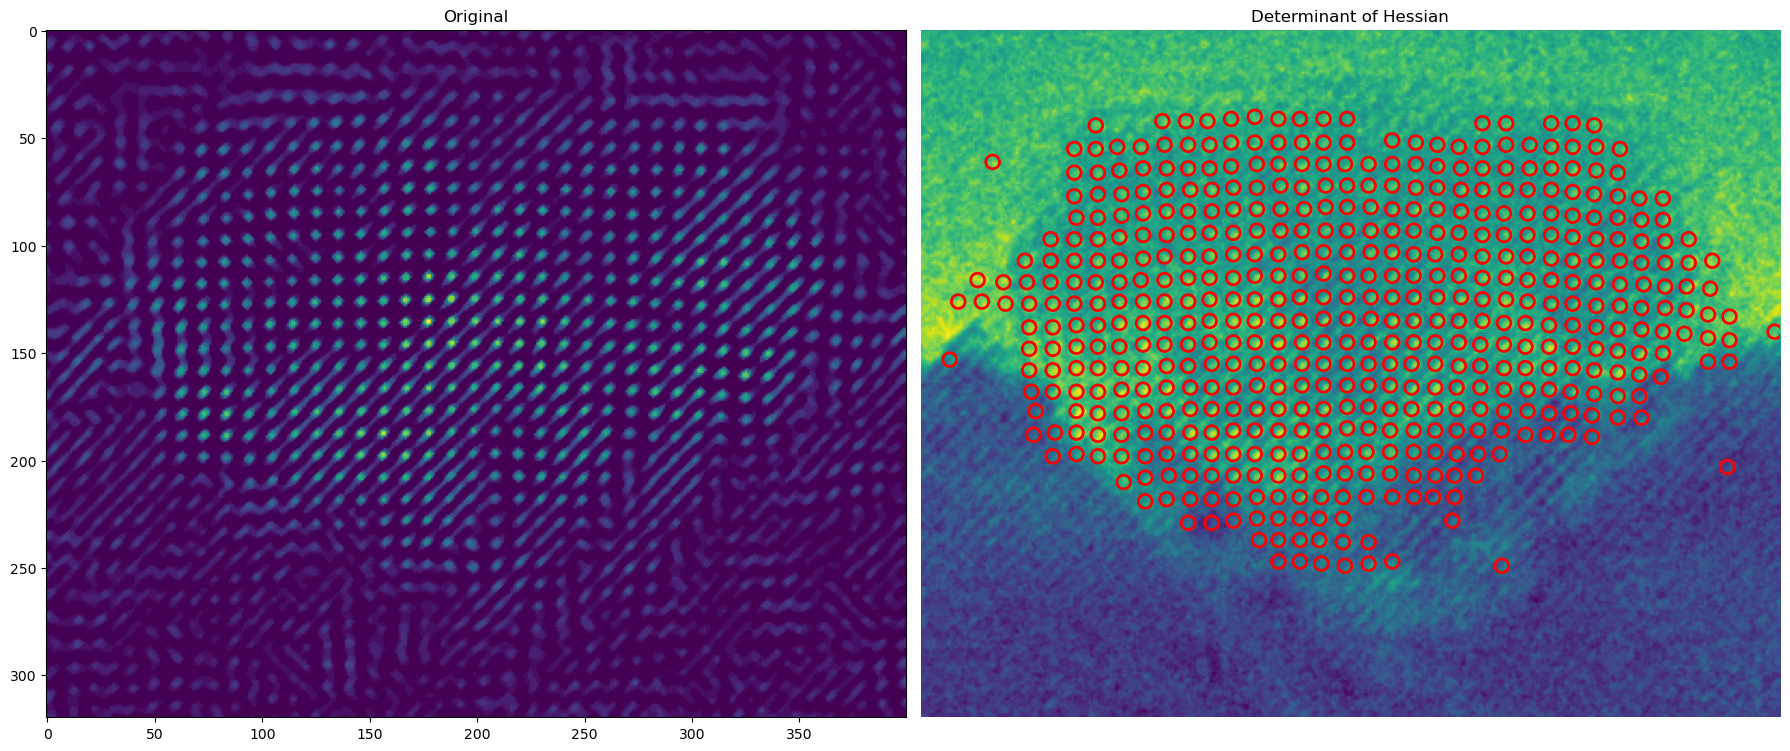

In [2]:
#blob detection using Determinant of Hessian (DoH)
#Test parameters on singel frames
from math import sqrt
from skimage import data
from skimage.feature import blob_dog, blob_log, blob_doh
from skimage.color import rgb2gray
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage

j=100


w2=400
h2=320



fr=img[j]
nFrames,h,w=img.shape

b1=int((h-h2)/2)
b1max=h-b1
# print(b1,b1max)
b2=int((w-w2)/2)
b2max=w-b2

fr=fr[b1:b1max,b2:b2max]
image = fr
rimg= Rimg[j]
rimg=rimg[b1:b1max,b2:b2max]
dpmed=5
image=cv2.medianBlur(image,dpmed)

bthrs=0.000025
smax=3.2
smin=2.7
# image_gray = ndimage.maximum_filter(image_gray, size=2, mode='constant')

# blobs_log = blob_log(image_gray, max_sigma=3, num_sigma=1, threshold=.025)

# # Compute radii in the 3rd column.
# blobs_log[:, 2] = blobs_log[:, 2] * sqrt(2)

# blobs_dog = blob_dog(image_gray, max_sigma=3, threshold=.025)
# blobs_dog[:, 2] = blobs_dog[:, 2] * sqrt(2)

blobs_doh = blob_doh(image, max_sigma=smax, min_sigma=smin, overlap=0,threshold=bthrs)
# min_sigma float, optional
# The minimum standard deviation for Gaussian Kernel used to compute Hessian matrix. Keep this low to detect smaller blobs.

# max_sigma float, optional
# The maximum standard deviation for Gaussian Kernel used to compute Hessian matrix. Keep this high to detect larger blobs.

# num_sigma int, optional
# The number of intermediate values of standard deviations to consider between min_sigma and max_sigma.

# overlap float, optional
# A value between 0 and 1. If the area of two blobs overlaps by a fraction greater than threshold, the smaller blob is eliminated.

color = 'red'
title = 'Determinant of Hessian'
# sequence = zip(blobs_list, colors, titles)

fig, axes = plt.subplots(1, 2, figsize=(18, 9), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].set_title('Original')
ax[0].imshow(image)

ax[1].set_title(title)
ax[1].imshow(rimg)
for blob in blobs_doh:
    y, x, r = blob
    c = plt.Circle((x, y), r, color=color, linewidth=2, fill=False)
    ax[1].add_patch(c)
ax[1].set_axis_off()
    
    

plt.tight_layout()
plt.show()

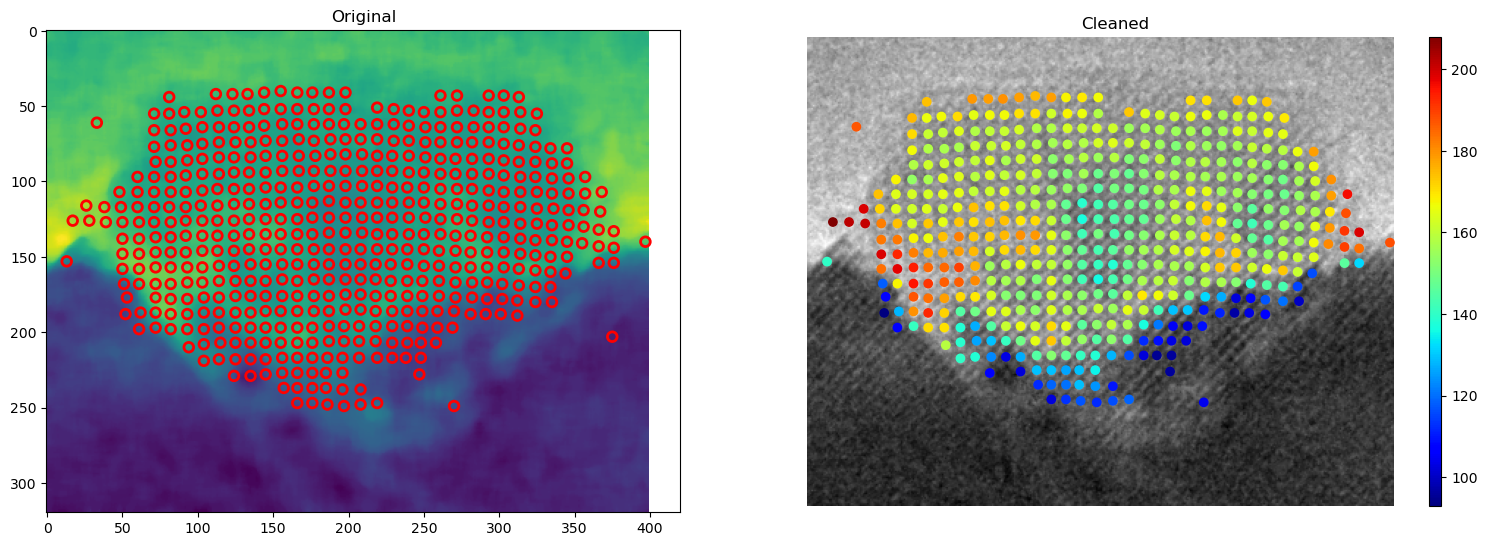

In [3]:
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

#Clean data based on intensity in real image
import numpy as np
thrs=85
thrs2=210
blurred_img =cv2.medianBlur(rimg,11)
h,w=rimg.shape
fig, axes = plt.subplots(1, 2, figsize=(18, 9), sharex=True, sharey=True)
ax = axes.ravel()


ax[0].set_title('Original')
ax[0].imshow(blurred_img)
for blob in blobs_doh:
    y, x, r = blob
    c = plt.Circle((x, y), r, color=color, linewidth=2, fill=False)
    ax[0].add_patch(c)


    
ax[1].set_title('Cleaned')
ax[1].imshow(rimg,cmap='gray')
X=[]
Y=[]
I=[]
disk=1
for blob in blobs_doh:
    y, x, r = blob
    if (x>disk and x<(w-disk) and y>disk and y<(h-disk)):
        x_l=int(x-disk)
        x_r=int(x+disk)
        y_l=int(y-disk)
        y_r=int(y+disk)
        intensity=int(np.mean(blurred_img[y_l:y_r,x_l:x_r]))
    else:
        intensity=255
#     x_l=int(x-disk)
#     x_r=int(x+disk)
#     y_l=int(y-disk)
#     y_r=int(y+disk)
#     intensity=int(np.mean(blurred_img[y_l:y_r,x_l:x_r]))
#     print(intensity)
    if intensity>thrs and intensity<thrs2:
        X.append(x)
        Y.append(y)
        I.append(intensity)
c = plt.scatter(X, Y, c=I, cmap=plt.cm.jet)
divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="2%", pad=0.05)
plt.colorbar(c, cax=cax)
#     ax[1].add_patch(c)
  

ax[1].set_axis_off()
# cbar = fig.colorbar(c, orientation='horizontal')  

48.0 368.0


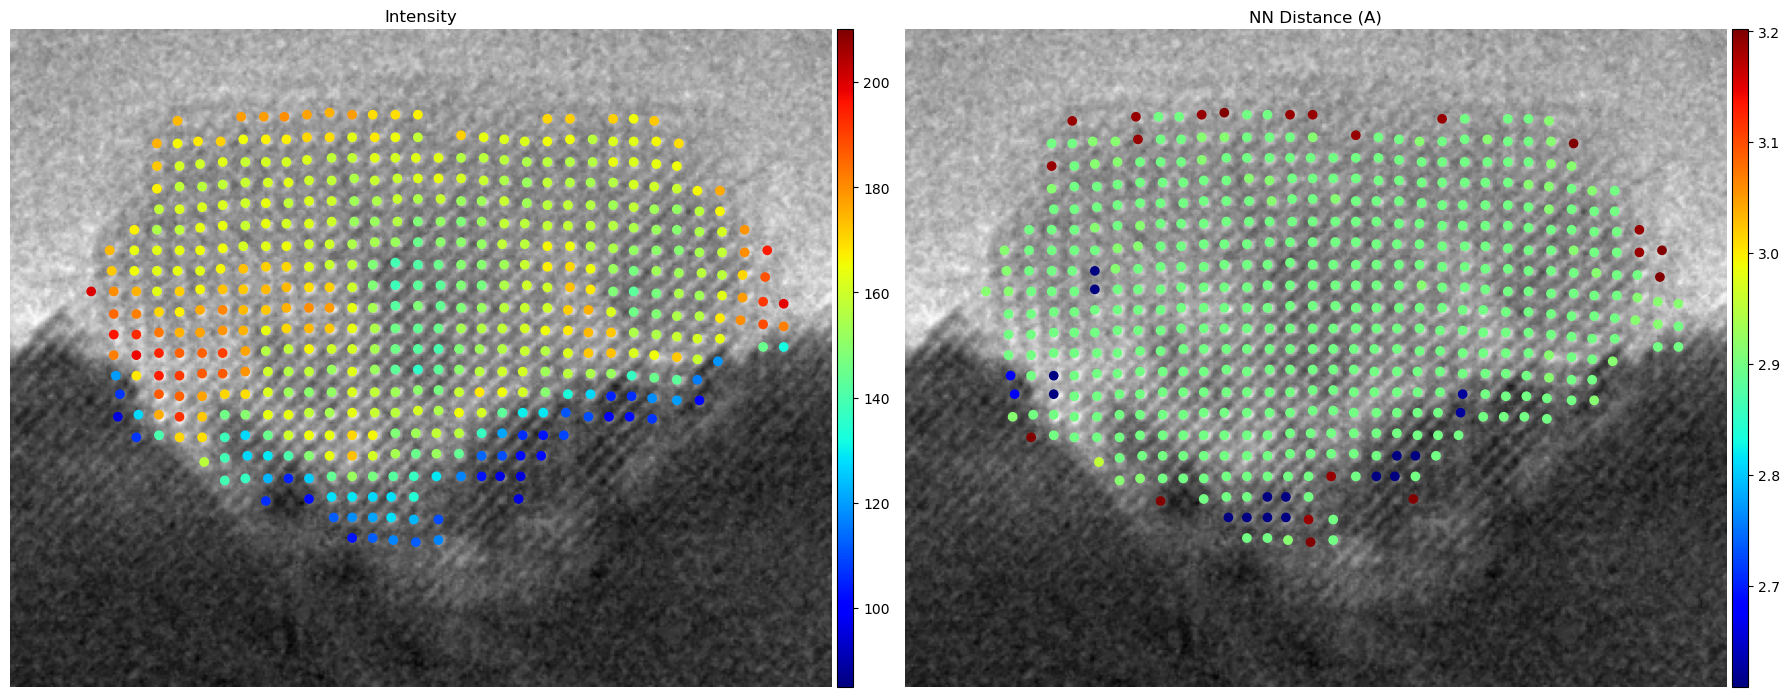

In [4]:
#clean data that does not belong to the isalnd based on NN distance
# print(blobs_doh)#y,x,r
from sklearn.neighbors import NearestNeighbors
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

scale=3.45 #px/A
blob =blobs_doh
blurred_img =cv2.medianBlur(rimg,11)
h,w=rimg.shape
# print(blob)

X=np.array(X)
Y=np.array(Y)
P=np.column_stack((Y,X))
# print(P)
nbrs = NearestNeighbors(n_neighbors=7, algorithm='auto').fit(P)
distances, indices = nbrs.kneighbors(P)
d1_min=8.6 #Minum DNN
d1_max=12
d_max=15 #maxium NN distance
d2_max=25

D=[]
X2=[]
Y2=[]
I=[]
# thrs=120
# thrs2=210
disk=3

for i in range(len(distances)):
    d1=distances[i,1]
    d=distances[i,2]
    d3=distances[i,3]
    d2=distances[i,6]
    y=P[i,0]
    x=P[i,1]
    
    d=distances[i,1]/scale
    #remove points on the edge
    
    if (x>disk and x<(w-disk) and y>disk and y<(h-disk)):
        x_l=int(x-disk)
        x_r=int(x+disk)
        y_l=int(y-disk)
        y_r=int(y+disk)
        intensity=int(np.mean(blurred_img[y_l:y_r,x_l:x_r]))
    else:
        intensity=255
            
        
#     token1 = (intensity>thrs and intensity <thrs2)
    
#     if token1 == True:

    token2 = (d1>d1_min and d1<d1_max and d<d_max and d2<d2_max)
    if token2 == True:
        D.append(d)
        X2.append(x)
        Y2.append(y)    
        I.append(intensity)


#Clean data with x coordinates
line=[]



for m in range(len(X2)):
    x=X2[m]
    y=Y2[m]
    if abs(y-100)<10:
#         plt.plot(X2[m],Y2[m],'y*')
        line.append(x)
print(min(line),max(line)) 

err=10 
Point = []
for m in range(len(X2)):
    x=X2[m]
    if x-min(line)>-err and x-max(line)<err:
        data=[X2[m],Y2[m],D[m],I[m]]
        Point.append(data)
Point=np.array(Point)
Point=Point[np.lexsort(np.transpose(Point)[::-1])]#sort




X3=Point[:,0]
Y3=Point[:,1]
D3=Point[:,2]
I3=Point[:,3]

#plot result

fig, axes = plt.subplots(1, 2, figsize=(18, 9), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].set_title('Intensity')
ax[0].imshow(rimg,cmap='gray')
imap = ax[0].scatter(X3,Y3, c=I3,cmap=plt.cm.jet,vmin=thrs, vmax=thrs2)
divider = make_axes_locatable(ax[0])
cax = divider.append_axes("right", size="2%", pad=0.05)
plt.colorbar(imap, cax=cax)
ax[0].set_axis_off()


ax[1].set_title('NN Distance (A)')
ax[1].imshow(rimg,cmap='gray')


c = ax[1].scatter(X3,Y3, c=D3,cmap=plt.cm.jet)

ax[1].set_axis_off()   
divider = make_axes_locatable(ax[1])
cax = divider.append_axes("right", size="2%",  pad=0.05)
plt.colorbar(c, cax=cax)
    

plt.tight_layout()
pathout = path[:-4]+'_'+str(j)+'.png'
plt.savefig(pathout)
plt.show()


In [8]:
#Apply to image stack
#blob detection using Determinant of Hessian (DoH)
# It detects blobs by finding maximas in the matrix of the Determinant of Hessian of the image. The detection speed is independent of the size of blobs as internally the implementation uses box filters instead of convolutions. 
# Bright on dark as well as dark on bright blobs are detected. The downside is that small blobs (<3px) are not detected accurately. See skimage.feature.blob_doh() for usage.
# from skimage import data
from skimage.feature import blob_doh
# from skimage.color import rgb2gray

from sklearn.neighbors import NearestNeighbors
import numpy as np
import insituTEM.insitu_IO as IO
import matplotlib.pyplot as plt
import easygui
import cv2
import tifffile
import tqdm
import insituTEM.insitu_DP as DP

# path =  easygui.fileopenbox("Select the IFFT stack")
# pathr =  easygui.fileopenbox("Select the image stack")
Pointout = path[:-4]+'_Blob3.csv'
Imgout = path[:-4]+'_Blob2.tif' #outputs the detected points overlay on the original image
Maskout = path[:-4]+'_BlobMask.tif' # outputs mask with only the detected points

# img = tifffile.imread(path)
# Rimg = tifffile.imread(pathr)
nFrames, h,w = Rimg.shape



# i=80
color = 0


# d1_min=8 #Minum DNN
# d1_max=12
# d_max=15 #maxium NN distance
# d2_max=25
# Points = [] #[f, y,x]
radius =1



disk=3
# thrs=120
# thrs2=210
# startpoint=[200,200]


Points = []
print("---------------------------------------------")
print('Atom location detection start!') 
# nFrames=700

with tifffile.TiffWriter(Imgout,bigtiff=True) as tif, tifffile.TiffWriter(Maskout,bigtiff=True) as tif2:

    for i in tqdm.tqdm(range(nFrames)):
        fr=img[i]
        rfr=Rimg[i]
        fr=fr[b1:b1max,b2:b2max]
    #     rfr = np.roll(rfr, 5, axis=0) # To accomodate the slight image shift between IFFT and Rimg

        rfr=rfr[b1:b1max,b2:b2max]
        height, width = rfr.shape
        mask=255 * np.ones((height, width), dtype=np.uint8)
        blurred_img =cv2.medianBlur(rfr,11)
        image=cv2.medianBlur(fr,dpmed)

    #     fig,ax=plt.subplots(figsize=(7, 6))
    #     im=ax.imshow(rfr,cmap='gray')

        #Blob detection on IFFT image
        X1=[]
        Y1=[]
        blobs = blob_doh(image, max_sigma=smax, min_sigma=smin, overlap=0.1,threshold=bthrs)

        #clean using intensity
        for blob in blobs:
            y, x,r = blob
            if (x>disk and x<(w-disk) and y>disk and y<(h-disk)):
                x_l=int(x-disk)
                x_r=int(x+disk)
                y_l=int(y-disk)
                y_r=int(y+disk)
                intensity=int(np.mean(blurred_img[y_l:y_r,x_l:x_r]))
            else:
                intensity=255

            if intensity>thrs and intensity<thrs2:
                X1.append(x)
                Y1.append(y)
    #     imap =plt.scatter(X1,Y1)
    #     plt.title('Intensity cleanned')    

        #Cleanning using NN distances
        X2=[]
        Y2=[]
        I=[]
        D=[]
        X1=np.array(X1)
        Y1=np.array(Y1)
        P1=np.column_stack((Y1,X1))
        nbrs = NearestNeighbors(n_neighbors=7, algorithm='auto').fit(P1)
        distances, indices = nbrs.kneighbors(P1)
        for j in range(len(distances)):
            d=distances[j,1]
            d1=distances[j,2]
    #         d3=distances[j,3]
    #         d2=distances[j,6]
            x=X1[j]
            y=Y1[j]
            x_l=int(x-disk)
            x_r=int(x+disk)
            y_l=int(y-disk)
            y_r=int(y+disk)
            intensity=int(np.mean(blurred_img[y_l:y_r,x_l:x_r]))
            token2 = (d>d1_min and d<d1_max and d1<d_max)
            if token2 == True:
    #             data=[i, x, y, d1, intensity]
    #             cv2.circle(fr, (int(P1[j,1]),int(P1[j,0])), radius, color, -1)    #Export to image


    #             Point.append(data)
                D.append(d*1000/scale)#the saved csv are int. enlarge D to avoid corp
                X2.append(x)
                Y2.append(y)    
                I.append(intensity)

    #     fig,ax=plt.subplots(figsize=(7, 6))
    #     im=ax.imshow(rfr,cmap='gray')
    #     im =plt.scatter(X2,Y2)
    #     plt.title('NN cleanned') 

    #     plt.axis('off')

        #Clean data with x coordinates
        line=[]
    #     for m in range(len(X2)):
    #         x=X2[m]
    #         y=Y2[m]
    #         if abs(y-200)<200:
    #             line.append(x)
    # #         print(min(line),max(line)) 
    #     err=10 
        Point=[]

        for m in range(len(X2)):
            x=X2[m]
            # if x-min(line)>-err and x-max(line)<err:
            if abs(y-200)<200:
                data=[i,X2[m],Y2[m],D[m],I[m]]
                Points.append(data)
                Point.append(data)
                cv2.circle(rfr, (int(X2[m]),int(Y2[m])), radius, color, -1)    #Export to image
                cv2.circle(mask, (int(X2[m]),int(Y2[m])), 3, color, -1)    #Export to mask using circles as atom position


        tif.write(rfr, contiguous=True)
        tif2.write(mask, contiguous=True)



#         if i == 0:      
#             tifffile.imwrite(Imgout,rfr,append=False)
#     #         tiffile.imsave(Imgout,fr, append=False)
#             tifffile.imwrite(Maskout,mask,append=False)

#         else:            
#             tifffile.imwrite(Imgout,rfr, append=True)
#             tifffile.imwrite(Maskout,mask,append=True)


    
# #save csv of points
Points=np.array(Points)
Pointsort=Points[np.lexsort(np.transpose(Points)[::-1])]
IO.writeCSV(Pointout,Pointsort)
print("---------------------------------------------")
print('Done! Enjoy~')


---------------------------------------------
Atom location detection start!


100%|███████████████████████████████████████████| 698/698 [01:02<00:00, 11.14it/s]


---------------------------------------------
Done! Enjoy~


In [21]:
Points=np.array(Points)
Pointsort=Points[np.lexsort(np.transpose(Points)[::-1])]
IO.writeCSV(Pointout,Pointsort)
# print(Pointsort)